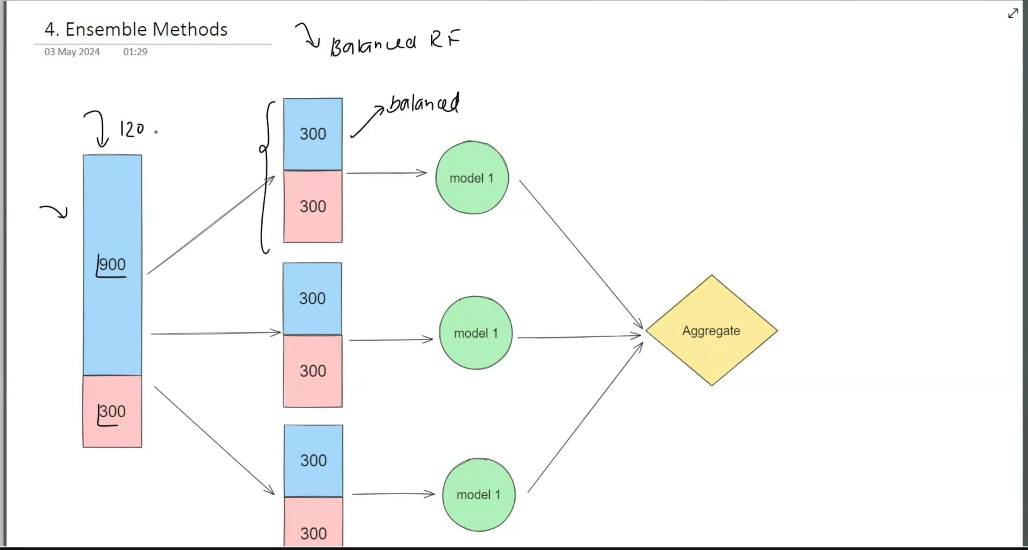

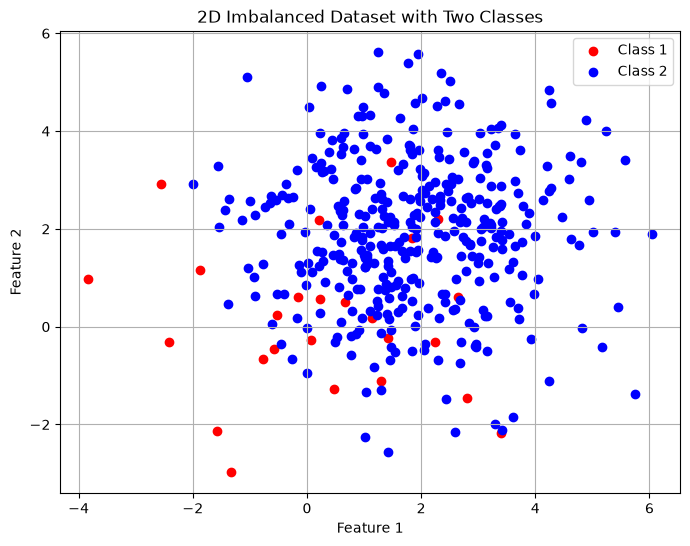

In [3]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate imbalanced dataset
n_samples_1 = 25  # Number of samples in class 1
n_samples_2 = 375  # Number of samples in class 2
centers = [(0, 0), (2, 2)]  # Centers of each cluster
cluster_std = [1.5, 1.5]  # Standard deviation of each cluster

X, y = make_blobs(n_samples=[n_samples_1, n_samples_2],
                  centers=centers,
                  cluster_std=cluster_std,
                  random_state=0)
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y)

In [6]:
classifer = BalancedRandomForestClassifier()
classifer.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [9]:
y_pred_brf=classifer.predict(X_test)

In [12]:
y_proba_brf=classifer.predict_proba(X_test)[:,1]

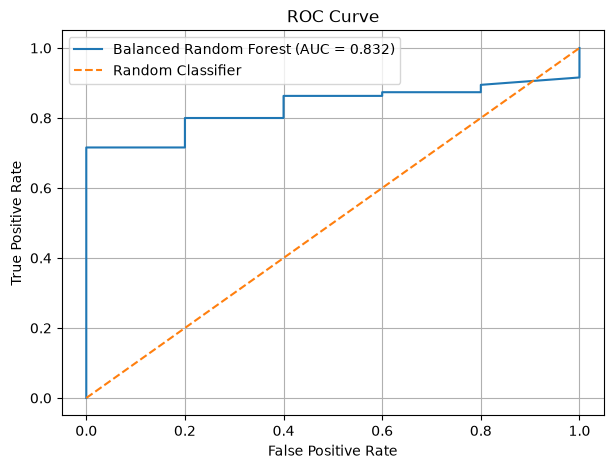

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_brf)
auc_score = roc_auc_score(y_test, y_proba_brf)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Balanced Random Forest (AUC = {auc_score:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
auc_score

0.8315789473684211

In [20]:
thresholds

array([ inf, 0.98, 0.97, 0.96, 0.94, 0.93, 0.92, 0.91, 0.9 , 0.89, 0.88,
       0.87, 0.86, 0.83, 0.8 , 0.79, 0.78, 0.77, 0.73, 0.72, 0.71, 0.69,
       0.68, 0.65, 0.63, 0.6 , 0.57, 0.54, 0.53, 0.51, 0.46, 0.44, 0.42,
       0.38, 0.34, 0.32, 0.1 , 0.09])